# Clustering con KMeans en Databricks Free Edition
# Dataset: Adult Income
# Objetivo:
# 1. Preparar datos con Spark
# 2. Construir features para clustering
# 3. Entrenar KMeans
# 4. Evaluar con silhouette
# 5. Registrar parámetros y métricas con MLflow

In [ ]:
import findspark
findspark.init('/spark-3.5.1-bin-hadoop3')
from pyspark import *
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
import pandas as pd


spark = SparkSession.builder.appName("analytics").getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/30 18:05:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/30 18:05:49 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/03/30 18:05:49 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


In [3]:
from pyspark.sql.types import *
from pyspark.sql.functions import col, trim, when, avg, count
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.functions import vector_to_array

# import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import gc

In [5]:
raw_schema = StructType([
    StructField("age", StringType(), True),
    StructField("workclass", StringType(), True),
    StructField("fnlwgt", StringType(), True),
    StructField("education", StringType(), True),
    StructField("education_num", StringType(), True),
    StructField("marital_status", StringType(), True),
    StructField("occupation", StringType(), True),
    StructField("relationship", StringType(), True),
    StructField("race", StringType(), True),
    StructField("sex", StringType(), True),
    StructField("capital_gain", StringType(), True),
    StructField("capital_loss", StringType(), True),
    StructField("hours_per_week", StringType(), True),
    StructField("native_country", StringType(), True),
    StructField("income", StringType(), True)
])

df_raw = (
    spark.read
    .option("header", "false")
    .option("sep", ",")
    .option("ignoreLeadingWhiteSpace", "true")
    .option("ignoreTrailingWhiteSpace", "true")
    .schema(raw_schema)
    .csv("data/adult.data")
)

for c in df_raw.columns:
    df_raw = df_raw.withColumn(c, trim(col(c)))

display(df_raw.limit(10))
print("Filas originales:", df_raw.count())

DataFrame[age: string, workclass: string, fnlwgt: string, education: string, education_num: string, marital_status: string, occupation: string, relationship: string, race: string, sex: string, capital_gain: string, capital_loss: string, hours_per_week: string, native_country: string, income: string]

Filas originales: 32561


In [6]:
string_cols = [
    "workclass", "education", "marital_status", "occupation",
    "relationship", "race", "sex", "native_country", "income"
]

for c in string_cols:
    if c != "income":
        df_raw = df_raw.withColumn(c, when(col(c) == "?", None).otherwise(col(c)))

df = (
    df_raw
    .withColumn("age", col("age").cast("int"))
    .withColumn("fnlwgt", col("fnlwgt").cast("int"))
    .withColumn("education_num", col("education_num").cast("int"))
    .withColumn("capital_gain", col("capital_gain").cast("int"))
    .withColumn("capital_loss", col("capital_loss").cast("int"))
    .withColumn("hours_per_week", col("hours_per_week").cast("int"))
    .dropna()
)

print("Filas después de limpieza:", df.count())
display(df.limit(10))

Filas después de limpieza: 30162


DataFrame[age: int, workclass: string, fnlwgt: int, education: string, education_num: int, marital_status: string, occupation: string, relationship: string, race: string, sex: string, capital_gain: int, capital_loss: int, hours_per_week: int, native_country: string, income: string]

In [7]:
display(df.groupBy("income").count())
display(df.groupBy("sex").count())
display(df.select("age", "education_num", "hours_per_week", "capital_gain", "capital_loss"))

DataFrame[income: string, count: bigint]

DataFrame[sex: string, count: bigint]

DataFrame[age: int, education_num: int, hours_per_week: int, capital_gain: int, capital_loss: int]

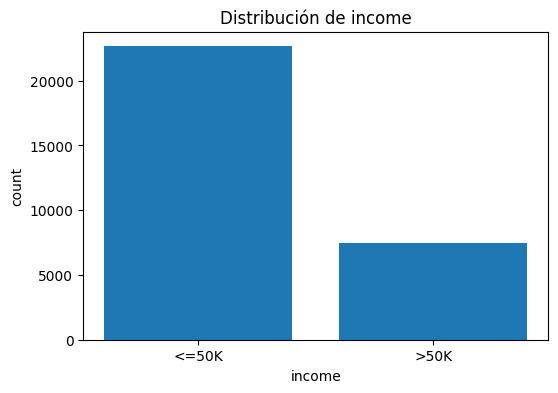

In [8]:
income_pd = df.groupBy("income").count().toPandas()

plt.figure(figsize=(6,4))
plt.bar(income_pd["income"], income_pd["count"])
plt.title("Distribución de income")
plt.xlabel("income")
plt.ylabel("count")
plt.show()

In [9]:
categorical_cols = [
    "workclass", "education", "marital_status", "occupation",
    "relationship", "race", "sex", "native_country"
]

numeric_cols = [
    "age", "fnlwgt", "education_num", "capital_gain",
    "capital_loss", "hours_per_week"
]

In [10]:
indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in categorical_cols
]

encoders = [
    OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe")
    for c in categorical_cols
]

assembler_inputs = numeric_cols + [f"{c}_ohe" for c in categorical_cols]

assembler = VectorAssembler(
    inputCols=assembler_inputs,
    outputCol="features_raw"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=False
)

In [14]:
def cleanup_kmeans_vars():
    for name in [
        "kmeans_model", "pipeline_model", "predictions",
        "cluster_sample_pd", "cluster_sizes_pd", "summary_pd"
    ]:
        if name in globals():
            del globals()[name]
    gc.collect()


def train_evaluate_kmeans(k, max_iter=20, seed=42):
    cleanup_kmeans_vars()

    kmeans = KMeans(
        featuresCol="features",
        predictionCol="prediction",
        k=k,
        maxIter=max_iter,
        seed=seed
    )

    pipeline = Pipeline(stages=indexers + encoders + [assembler, scaler, kmeans])

    pipeline_model = pipeline.fit(df)
    predictions = pipeline_model.transform(df)

    evaluator = ClusteringEvaluator(
        featuresCol="features",
        predictionCol="prediction",
        metricName="silhouette",
        distanceMeasure="squaredEuclidean"
    )

    silhouette = evaluator.evaluate(predictions)

    kmeans_model = pipeline_model.stages[-1]
    training_cost = kmeans_model.summary.trainingCost
    cluster_sizes = kmeans_model.summary.clusterSizes
    centers = kmeans_model.clusterCenters()

    result = {
        "k": k,
        "maxIter": max_iter,
        "silhouette": silhouette,
        "training_cost": float(training_cost)
    }

    cluster_sample_pd = (
        predictions
        .select(
            "age",
            "education",
            "occupation",
            "hours_per_week",
            "income",
            "prediction"
        )
        .limit(30)
        .toPandas()
    )

    cluster_sizes_pd = pd.DataFrame({
        "cluster": list(range(len(cluster_sizes))),
        "size": list(cluster_sizes)
    })

    centers_pd = pd.DataFrame(
        [c.tolist() if hasattr(c, 'tolist') else list(c) for c in centers]
    )

    summary_pd = (
        predictions
        .groupBy("prediction", "income")
        .count()
        .orderBy("prediction", "income")
        .toPandas()
    )

    del predictions
    del pipeline_model
    del kmeans_model
    gc.collect()

    return result, cluster_sample_pd, cluster_sizes_pd, centers_pd, summary_pd

In [15]:
result_k3, sample_k3, sizes_k3, centers_k3, summary_k3 = train_evaluate_kmeans(
    k=3,
    max_iter=20,
    seed=42
)

print(result_k3)
display(sample_k3)
display(sizes_k3)
display(summary_k3)

{'k': 3, 'maxIter': 20, 'silhouette': 0.06856868601577094, 'training_cost': 2987590.0710791694}


,age,education,occupation,hours_per_week,income,prediction
0,39,Bachelors,Adm-clerical,40,<=50K,2
1,50,Bachelors,Exec-managerial,13,<=50K,1
2,38,HS-grad,Handlers-cleaners,40,<=50K,0
3,53,11th,Handlers-cleaners,40,<=50K,1
4,28,Bachelors,Prof-specialty,40,<=50K,0
5,37,Masters,Exec-managerial,40,<=50K,0
6,49,9th,Other-service,16,<=50K,0
7,52,HS-grad,Exec-managerial,45,>50K,1
8,31,Masters,Prof-specialty,50,>50K,0
9,42,Bachelors,Exec-managerial,40,>50K,1


,cluster,size
0,0,16793
1,1,12090
2,2,1279


,prediction,income,count
0,0,<=50K,15106
1,0,>50K,1687
2,1,<=50K,6613
3,1,>50K,5477
4,2,<=50K,935
5,2,>50K,344


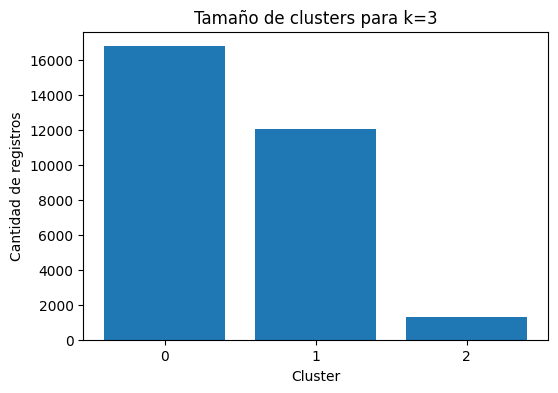

In [16]:
plt.figure(figsize=(6,4))
plt.bar(sizes_k3["cluster"].astype(str), sizes_k3["size"])
plt.title("Tamaño de clusters para k=3")
plt.xlabel("Cluster")
plt.ylabel("Cantidad de registros")
plt.show()

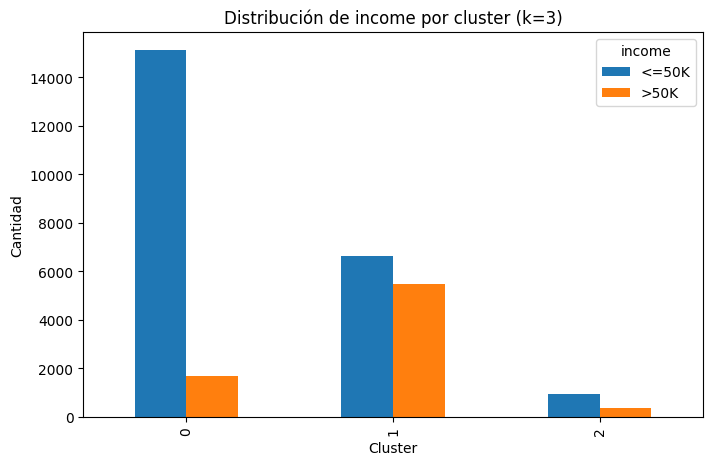

In [17]:
summary_pivot_k3 = summary_k3.pivot(index="prediction", columns="income", values="count").fillna(0)
summary_pivot_k3.plot(kind="bar", figsize=(8,5))
plt.title("Distribución de income por cluster (k=3)")
plt.xlabel("Cluster")
plt.ylabel("Cantidad")
plt.show()

In [18]:
results = []

for k in [2, 3, 4, 5, 6]:
    result, _, _, _, _ = train_evaluate_kmeans(k=k, max_iter=20, seed=42)
    results.append(result)

results_pd = pd.DataFrame(results)
display(spark.createDataFrame(results_pd))

DataFrame[k: bigint, maxIter: bigint, silhouette: double, training_cost: double]

## Métricas de evaluación de clustering

### Silhouette Score
El **coeficiente de silueta** mide qué tan bien asignado está cada punto a su cluster comparado con los clusters vecinos. Para cada punto se calcula:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\; b(i))}$$

Donde:
- $a(i)$ = distancia promedio del punto $i$ a los demás puntos de **su mismo cluster** (cohesión).
- $b(i)$ = distancia promedio del punto $i$ a los puntos del **cluster más cercano** al que no pertenece (separación).

| Rango | Interpretación |
|-------|---------------|
| $s \approx 1$ | Los clusters están bien definidos y separados. |
| $s \approx 0$ | Los clusters se solapan; los puntos están cerca del límite entre clusters. |
| $s < 0$ | Es probable que puntos estén asignados al cluster equivocado. |

**Mayor es mejor.** Se busca el $k$ que maximice el silhouette promedio.

---

### Training Cost (Within-Cluster Sum of Squares — WCSS)
El **costo de entrenamiento** es la suma de las distancias al cuadrado de cada punto a su centroide asignado:

$$\text{WCSS} = \sum_{j=1}^{k} \sum_{x_i \in C_j} \| x_i - \mu_j \|^2$$

Donde:
- $C_j$ = conjunto de puntos en el cluster $j$.
- $\mu_j$ = centroide del cluster $j$.

**Menor es mejor**, pero siempre decrece al aumentar $k$ (caso extremo: $k = n$ → costo = 0). Por ello se usa el **método del codo** (elbow method): buscar el punto donde la reducción de costo se desacelera significativamente.

---

## Comparación de múltiples valores de $k$

Se entrenó KMeans para $k \in \{2,3,4,5,6\}$ con `maxIter=20` y `seed=42`:

| k | Silhouette | Training cost |
|---|------------|---------------|
| 2 | 0.070863 | 3,019,254.05 |
| 3 | 0.068569 | 2,987,590.07 |
| 4 | 0.071597 | 2,955,834.99 |
| 5 | **0.075570** | 2,924,095.70 |
| 6 | 0.071540 | **2,900,783.24** |

### Decisión
Se selecciona **k = 5** como configuración principal: maximiza silhouette (mejor separación de clusters) aunque $k=6$ reduce más el costo, su silhouette empeora.

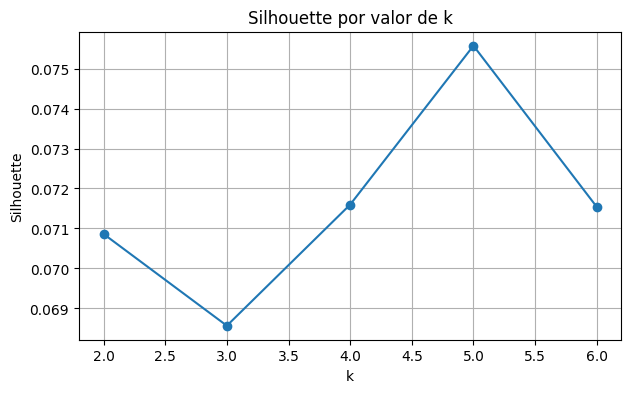

In [38]:
plt.figure(figsize=(7,4))
plt.plot(results_pd["k"], results_pd["silhouette"], marker="o")
plt.title("Silhouette por valor de k")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.grid(True)
plt.show()

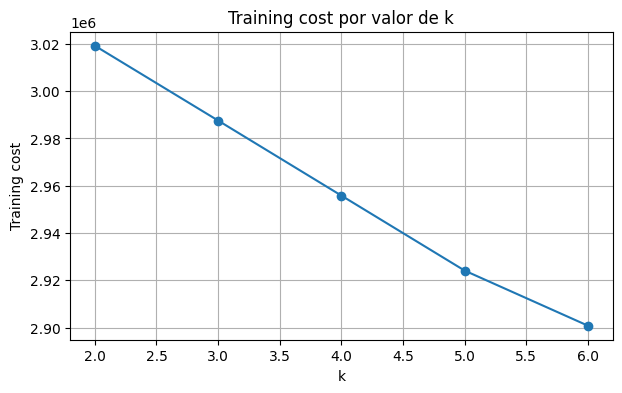

In [33]:
plt.figure(figsize=(7,4))
plt.plot(results_pd["k"], results_pd["training_cost"], marker="o")
plt.title("Training cost por valor de k")
plt.xlabel("k")
plt.ylabel("Training cost")
plt.grid(True)
plt.show()

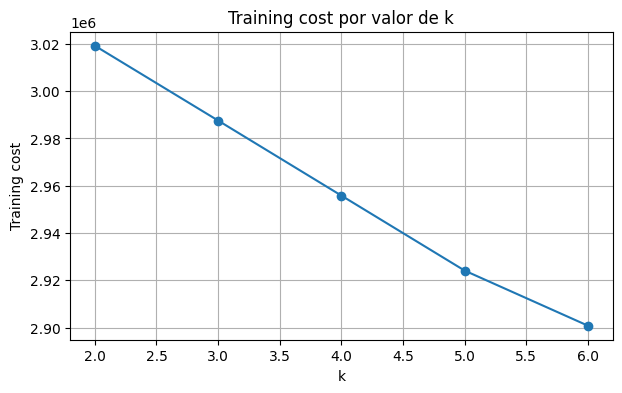

In [34]:
plt.figure(figsize=(7,4))
plt.plot(results_pd["k"], results_pd["training_cost"], marker="o")
plt.title("Training cost por valor de k")
plt.xlabel("k")
plt.ylabel("Training cost")
plt.grid(True)
plt.show()

In [35]:
best_k_row = results_pd.sort_values("silhouette", ascending=False).iloc[0]
best_k = int(best_k_row["k"])

best_result, best_sample, best_sizes, best_centers, best_summary = train_evaluate_kmeans(
    k=best_k,
    max_iter=20,
    seed=42
)

print(f"Mejor k = {best_k}")
print(best_result)
display(best_sample)
display(best_sizes)
display(best_summary)

Mejor k = 5
{'k': 5, 'maxIter': 20, 'silhouette': 0.07556989768648352, 'training_cost': 2924095.701681609}


,age,education,occupation,hours_per_week,income,prediction
0,39,Bachelors,Adm-clerical,40,<=50K,2
1,50,Bachelors,Exec-managerial,13,<=50K,1
2,38,HS-grad,Handlers-cleaners,40,<=50K,0
3,53,11th,Handlers-cleaners,40,<=50K,1
4,28,Bachelors,Prof-specialty,40,<=50K,0
5,37,Masters,Exec-managerial,40,<=50K,0
6,49,9th,Other-service,16,<=50K,4
7,52,HS-grad,Exec-managerial,45,>50K,1
8,31,Masters,Prof-specialty,50,>50K,0
9,42,Bachelors,Exec-managerial,40,>50K,1


,cluster,size
0,0,16009
1,1,11485
2,2,1273
3,3,940
4,4,455


,prediction,income,count
0,0,<=50K,14427
1,0,>50K,1582
2,1,<=50K,6292
3,1,>50K,5193
4,2,<=50K,929
5,2,>50K,344
6,3,<=50K,576
7,3,>50K,364
8,4,<=50K,430
9,4,>50K,25


In [36]:
cluster_profile = (
    df.join(
        spark.createDataFrame(best_sample[["age", "education", "occupation", "hours_per_week", "income", "prediction"]]),
        on=["age", "education", "occupation", "hours_per_week", "income"],
        how="inner"
    )
    .groupBy("prediction")
    .agg(
        avg("age").alias("avg_age"),
        avg("education_num").alias("avg_education_num"),
        avg("hours_per_week").alias("avg_hours_per_week"),
        avg("capital_gain").alias("avg_capital_gain")
    )
    .orderBy("prediction")
)

display(cluster_profile)

DataFrame[prediction: bigint, avg_age: double, avg_education_num: double, avg_hours_per_week: double, avg_capital_gain: double]

In [37]:
# Opcional: reentrenar localmente para perfilar clusters completos
kmeans = KMeans(featuresCol="features", predictionCol="prediction", k=best_k, maxIter=20, seed=42)
pipeline = Pipeline(stages=indexers + encoders + [assembler, scaler, kmeans])
pipeline_model = pipeline.fit(df)
predictions_best = pipeline_model.transform(df)

cluster_profile = (
    predictions_best
    .groupBy("prediction")
    .agg(
        avg("age").alias("avg_age"),
        avg("education_num").alias("avg_education_num"),
        avg("hours_per_week").alias("avg_hours_per_week"),
        avg("capital_gain").alias("avg_capital_gain"),
        count("*").alias("records")
    )
    .orderBy("prediction")
)

display(cluster_profile)

del predictions_best
del pipeline_model
gc.collect()

DataFrame[prediction: int, avg_age: double, avg_education_num: double, avg_hours_per_week: double, avg_capital_gain: double, records: bigint]

857